### Importation of librairies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, confusion_matrix, classification_report


import warnings
warnings.filterwarnings('ignore')

### Importation of dataset

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ML/projet_perso/booking/booking.csv')

### EDA

In [ ]:
data.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [ ]:
data.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


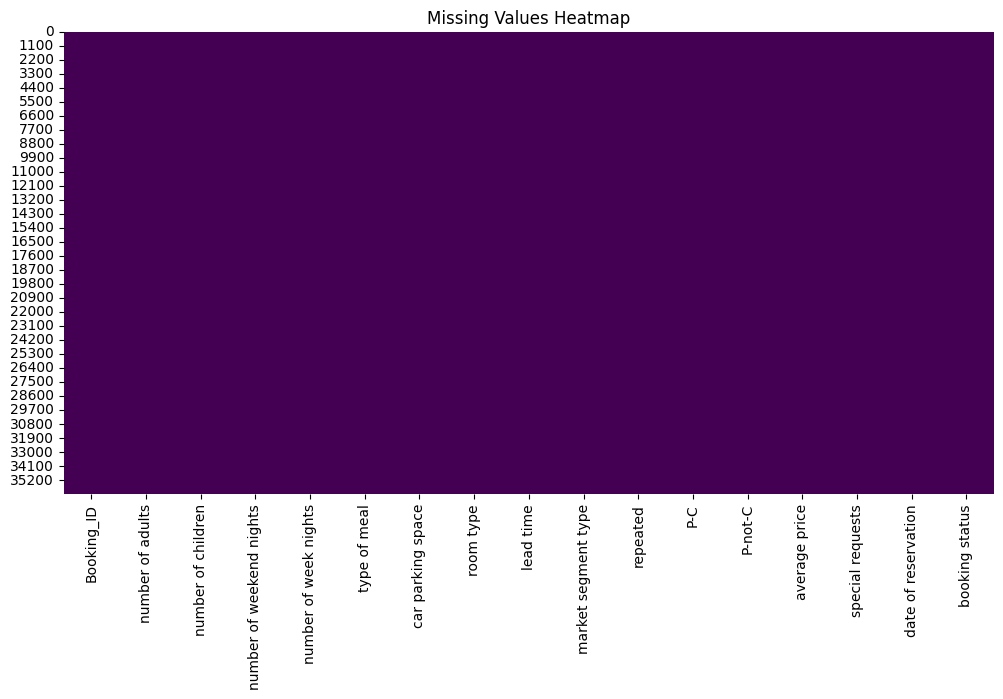

In [ ]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

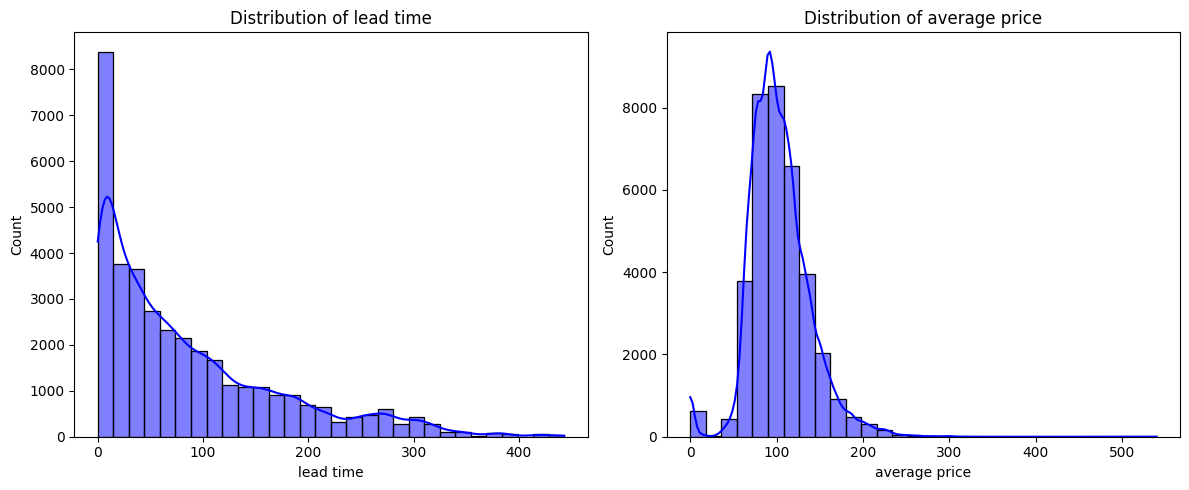

In [ ]:
# Continuous variables
continuous_vars = ["lead time", "average price"]

plt.figure(figsize=(12,5))
for i, col in enumerate(continuous_vars):
    plt.subplot(1, 2, i+1)
    sns.histplot(data[col], bins=30, kde=True, color="blue")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


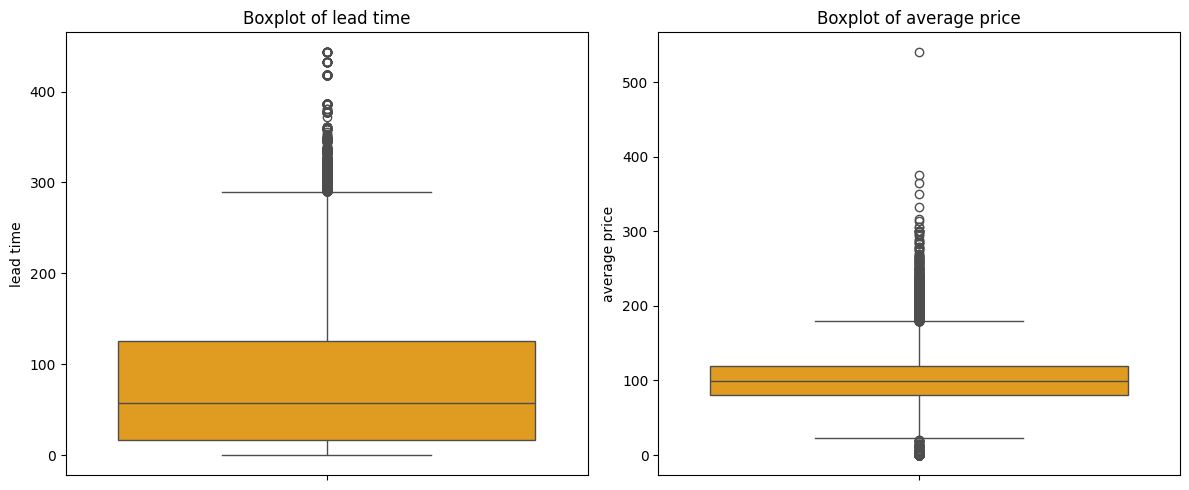

In [ ]:
# Boxplot of continuous variables
plt.figure(figsize=(12,5))
for i, col in enumerate(continuous_vars):
    plt.subplot(1, 2, i+1)
    sns.boxplot(y=data[col], color="orange")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

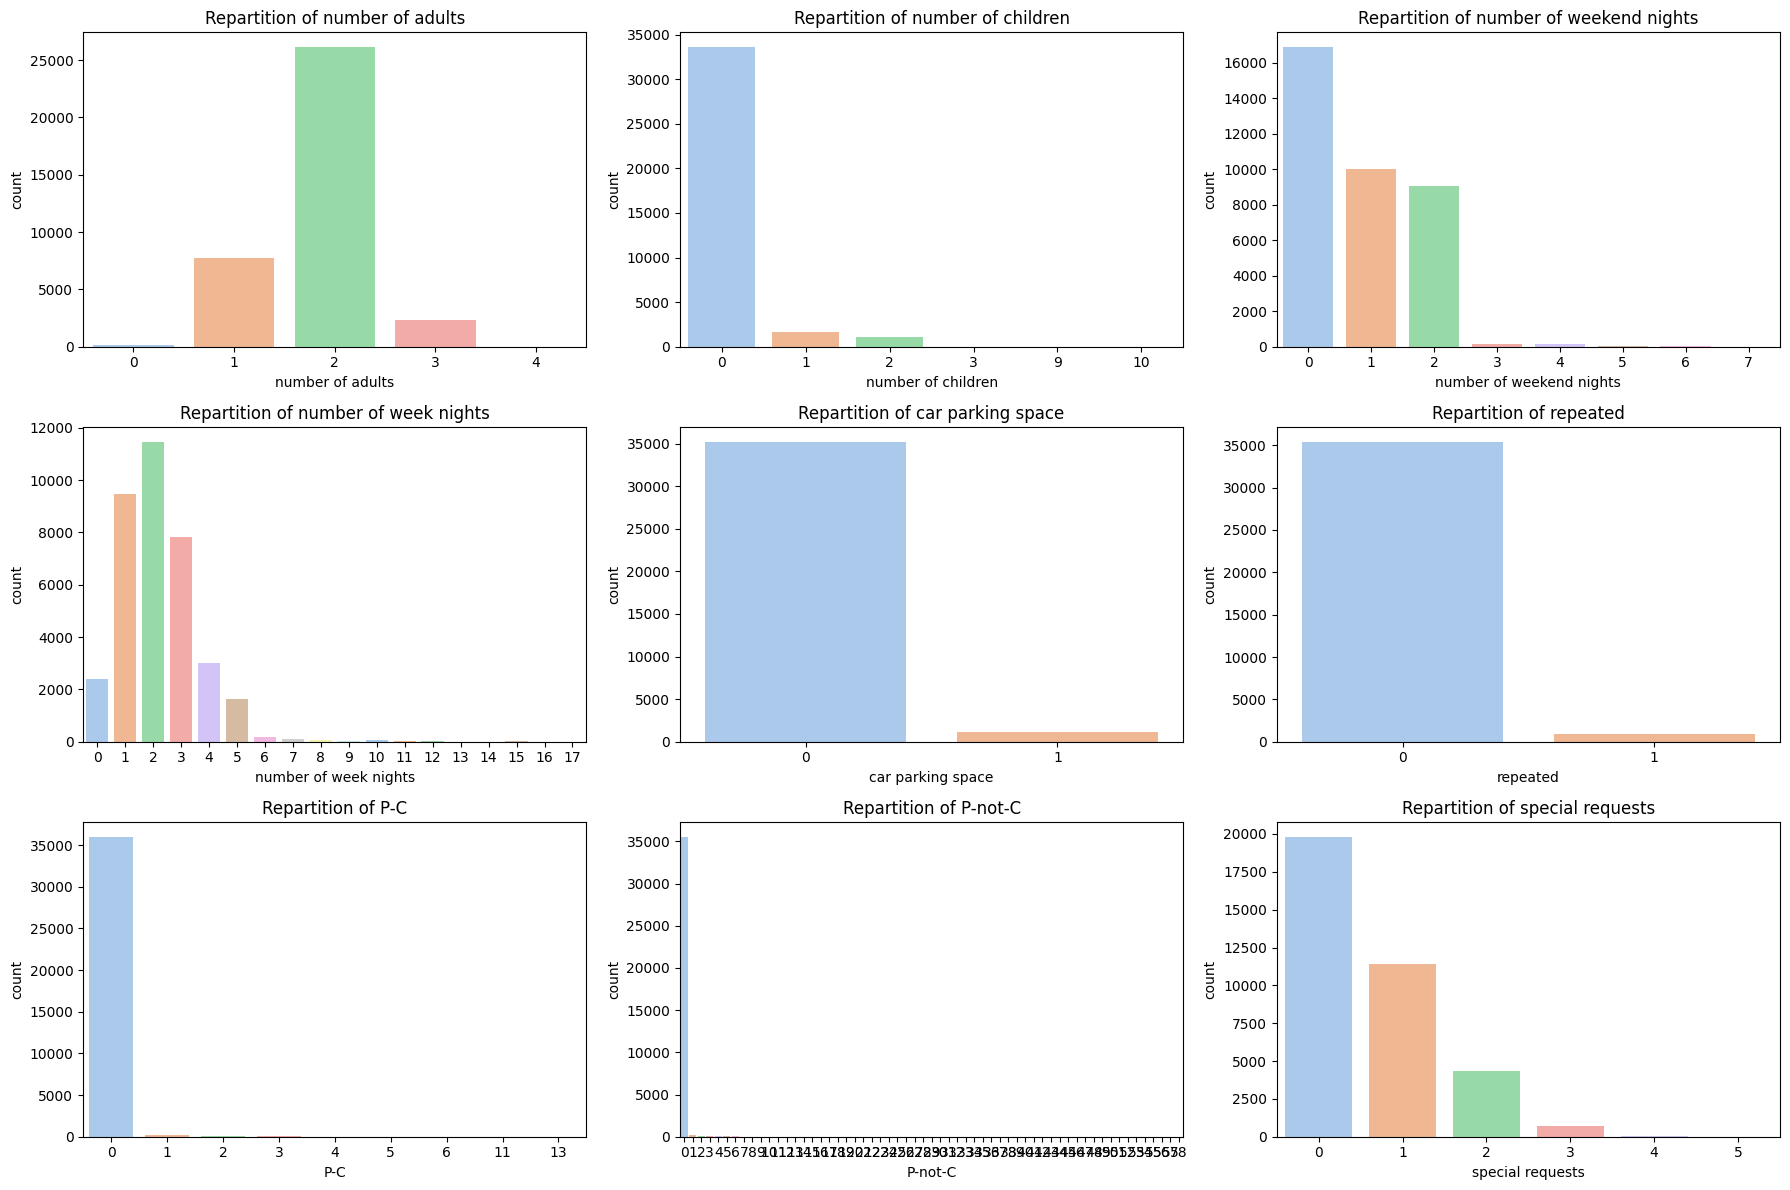

In [ ]:
# countplot of the distribution of the discrete_vars
discrete_vars = ['number of adults', 'number of children', 'number of weekend nights', 'number of week nights', 'car parking space', 'repeated', 'P-C', 'P-not-C', 'special requests']

plt.figure(figsize=(18,12))
for i, col in enumerate(discrete_vars):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=data[col], palette="pastel")
    plt.title(f"Repartition of {col}")
plt.tight_layout()
plt.show()

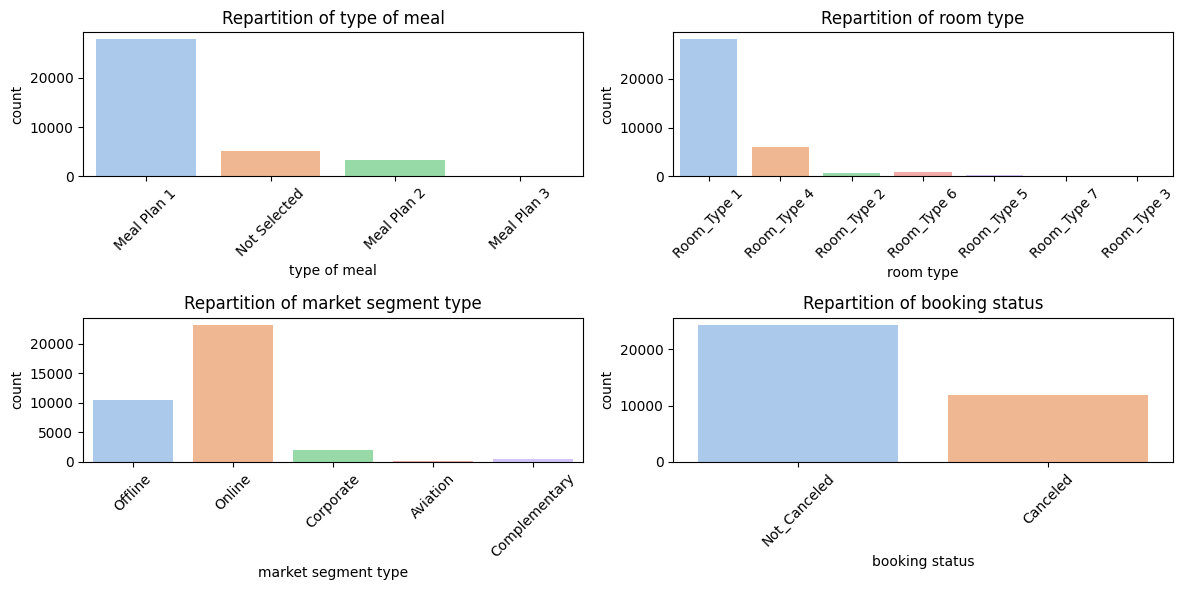

In [ ]:
# analyse of categorical variables
categorical_cols = ["type of meal", "room type", "market segment type", "booking status"]

plt.figure(figsize=(12,6))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=data[col], palette="pastel")
    plt.xticks(rotation=45)
    plt.title(f"Repartition of {col}")
plt.tight_layout()
plt.show()

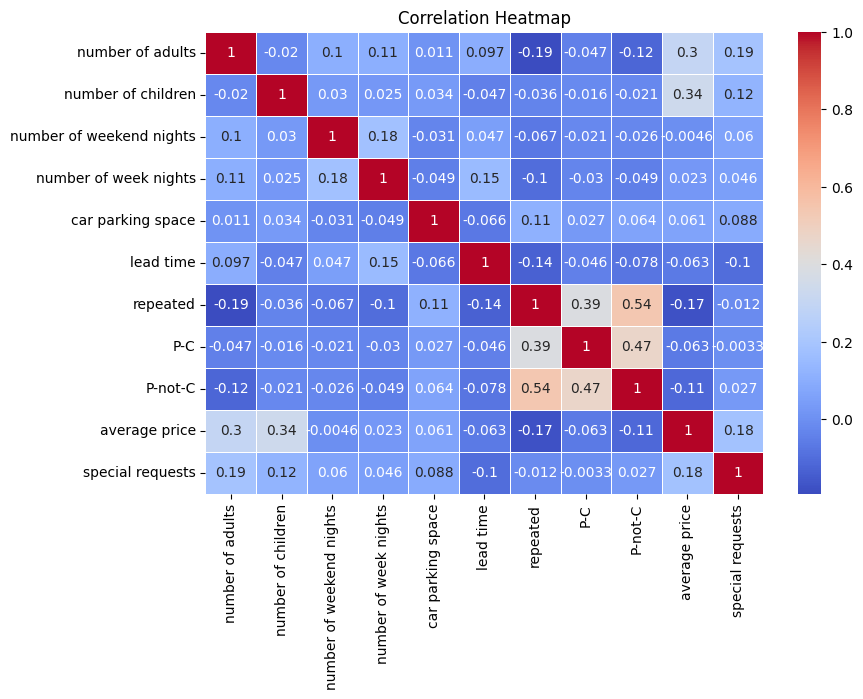

In [ ]:
# Correlation heatmap
plt.figure(figsize=(9, 6))
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

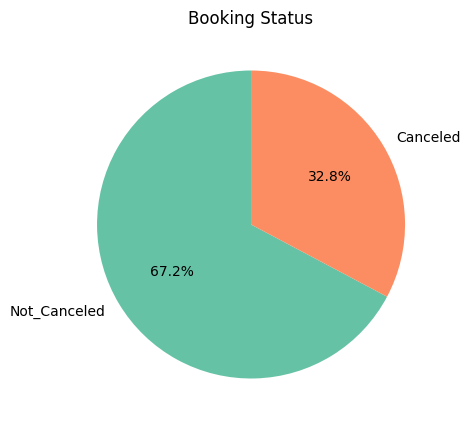

In [ ]:
# Booking status count
plt.figure(figsize=(7, 5))
data['booking status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
plt.title('Booking Status')
plt.ylabel('')
plt.show()

## Data preprocessing

In [ ]:
def preprocess_data(data):
    # Drop the Booking_ID column from the features
    data = data.drop(columns=['Booking_ID'])

    # **New: Feature Engineering**
    # Extract month from date of reservation and create a seasonality feature
    data['date of reservation'] = pd.to_datetime(data['date of reservation'], errors='coerce') # Convert to datetime, handle errors
    data.dropna(subset=['date of reservation'], inplace=True)  # remove rows with invalid dates after converting
    data['month'] = data['date of reservation'].dt.month
    data['season'] = data['month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                         'Spring' if x in [3, 4, 5] else
                                         'Summer' if x in [6, 7, 8] else
                                         'Autumn')  # No errors expected here

    # Feature engineering
    data['total_nights'] = data['number of weekend nights'] + data['number of week nights']
    data['total_people'] = data['number of adults'] + data['number of children']
    data['price_per_night'] = data['average price'] / (data['total_nights'] + 1)

    # Encode categorical variables
    data = pd.get_dummies(data, drop_first=True)

    # Drop the original 'date of reservation' column
    data = data.drop(columns=['date of reservation']) # Drop the original date column

    # Feature scaling
    scaler = StandardScaler()
    numeric_data = data.select_dtypes(include=[np.number])
    data[numeric_data.columns] = scaler.fit_transform(numeric_data)

    # Check the outliers and remove them
    z_scores = np.abs(stats.zscore(data.select_dtypes(include=[np.number])))
    data = data[(z_scores < 3).all(axis=1)]

    return data

In [ ]:
data_preprocessed = preprocess_data(data)

In [ ]:
# Split the data into features and target variable
X = data_preprocessed.drop('booking status_Not_Canceled', axis=1)
y = data_preprocessed['booking status_Not_Canceled']

# split the data into training and test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

## Model

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier() # New: Gradient boosting machine
}

# Define the parameter grid for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga']
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'XGBoost': {  # New: XGBoost parameters
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3]
    }
}

# Iterate over each model, perform grid search, fit it, and evaluate
best_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)
    # Fit on the SMOTE-oversampled data
    grid_search.fit(x_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(x_val)
    print(f'{name} - Best Params: {grid_search.best_params_}')
    print(f'{name} - F1 score: {f1_score(y_val, y_pred)}\n')
    best_models[name] = best_model

Training Logistic Regression...
Logistic Regression - Best Params: {'C': 0.1, 'solver': 'saga'}
Logistic Regression - F1 score: 0.8515759312320917

Training Decision Tree...
Decision Tree - Best Params: {'max_depth': 10, 'min_samples_split': 2}
Decision Tree - F1 score: 0.8950886370241209

Training Random Forest...
Random Forest - Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest - F1 score: 0.9147694103911267

Training XGBoost...
XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
XGBoost - F1 score: 0.9133489461358314



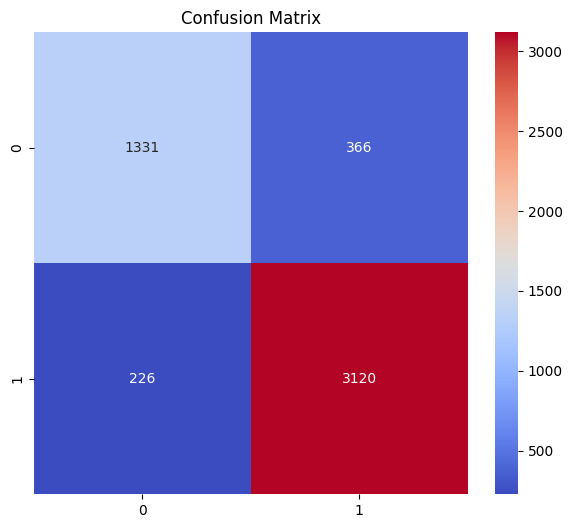

              precision    recall  f1-score   support

       False       0.85      0.78      0.82      1697
        True       0.90      0.93      0.91      3346

    accuracy                           0.88      5043
   macro avg       0.87      0.86      0.87      5043
weighted avg       0.88      0.88      0.88      5043



In [ ]:
# confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, cmap='coolwarm', fmt='0.0f')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_val, y_pred))

### Feature importance

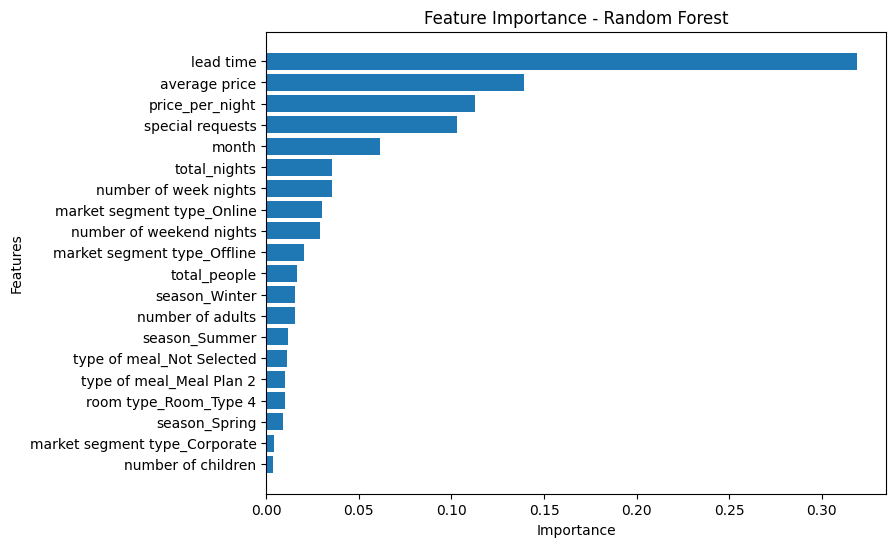

In [ ]:
# Feature importance for Random Forest
if hasattr(best_models['Random Forest'], 'feature_importances_'):
    importance = best_models['Random Forest'].feature_importances_
    features = X.columns

    sorted_indices = np.argsort(importance)[::-1]
    sorted_features = features[sorted_indices]
    sorted_importance = importance[sorted_indices]

    plt.figure(figsize=(8, 6))
    plt.barh(sorted_features[:20], sorted_importance[:20])
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.title("Feature Importance - Random Forest")
    plt.gca().invert_yaxis()
    plt.show()


In [ ]:
# final model iteration
model = RandomForestClassifier(
   max_depth = 20,
  min_samples_split = 5,
  n_estimators = 200
)
model.fit(x_train, y_train)

y_final = model.predict(x_test)

print(f'F1 score is {f1_score(y_test, y_final)}\n')


F1 score is 0.9174161896974653

